In [364]:
import torch

In [365]:
### Select device (GPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Selected device:', device)

Selected device: cuda


In [366]:
import string
all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

import unicodedata
# Turn a Unicode string to plain ASCII
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

import os
import glob
from io import open
for filename in glob.glob('../data-sets/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    lines = [unicodeToAscii(line) for line in lines]
    category_lines[category] = lines
    all_categories.append(category)

n_categories = len(category_lines.keys())

print('Amount of categories:', n_categories)
print('Some Dutch examples:', category_lines['Dutch'][:5])

Amount of categories: 18
Some Dutch examples: ['Aalsburg', 'Aalst', 'Aarle', 'Achteren', 'Achthoven']


In [367]:
char_to_num = {char: num for num, char in enumerate(all_letters)}
num_to_char = {num: char for char, num in char_to_num.items()}

cat_to_num = {cat: num for num, cat in enumerate(all_categories)}
num_to_cat = {num: cat for cat, num in cat_to_num.items()}

In [368]:
import torch
import random
import torch.nn.functional as F

word_length = 25

def encode_line(line):
    enc = torch.tensor([char_to_num[c] for c in line])
    one_hot_enc = F.one_hot(enc, num_classes=n_letters)
    
    # Pad with zeros
    padding_length = max(0, word_length - one_hot_enc.shape[0])
    pad_enc = F.pad(one_hot_enc, (0, 0, 0, padding_length), mode='constant', value=0)

    pad_enc = pad_enc.float()

    return pad_enc

def encode_category(category):
    enc = torch.tensor(cat_to_num[category])
    one_hot_enc = F.one_hot(enc, num_classes=n_categories)

    one_hot_enc = one_hot_enc.float()

    return one_hot_enc

def build_dataset(key, lines):
    X, Y = [], []

    for line in lines:
        X.append(encode_line(line))
        Y.append(encode_category(key))
    
    X = torch.stack(X)
    Y = torch.stack(Y)

    return X, Y

Xtr, Ytr = [], []
Xte, Yte = [], []

for key, lines in category_lines.items():
    lines = random.sample(lines, len(lines))
    split = int(0.8 * len(lines))

    Xtr_part, Ytr_part = build_dataset(key, lines[:split])
    Xte_part, Yte_part = build_dataset(key, lines[split:])

    Xtr.append(Xtr_part)
    Ytr.append(Ytr_part)
    Xte.append(Xte_part)
    Yte.append(Yte_part)

Xtr = torch.cat(Xtr, dim=0).to(device)
Ytr = torch.cat(Ytr, dim=0).to(device)
Xte = torch.cat(Xte, dim=0).to(device)
Yte = torch.cat(Yte, dim=0).to(device)

ix = random.randint(0, Xtr.shape[0] - 1)
print('Random example:', Xtr[ix].shape, '=>', Ytr[ix].shape)
print('Amount of train examples:', Xtr.shape[0])

Random example: torch.Size([25, 57]) => torch.Size([18])
Amount of train examples: 16053


In [369]:
import torch.nn as nn
from torch.autograd import Variable

n_hidden = 128

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.rnn(x, h0)

        out = self.fc(out[:, -1, :])
        return out

model = RNN(n_letters, n_hidden, n_categories).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 26258


In [370]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return list(category_lines.keys())[category_i], category_i

# input = encode_line('Albert').unsqueeze(0)
# hidden = torch.zeros(1, n_hidden)

# output, next_hidden = model(input, hidden)
# print(output)

# print(categoryFromOutput(output))

In [371]:
import torch.nn as nn
import torch.optim as optim

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [372]:
import torch.nn.functional as F

### Train MLP model ###
epochs = 1000
batch_size = 8
lr = 0.001
eval_batch_size = 10000

epoch_count = []
loss_values = []

from tqdm import trange
for epoch in trange(epochs):
    model.train()
    
    # Sample mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    output = model(Xb)

    loss = criterion(output, Yb)

    # Backpropagation and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Report progression every so often
    if ((epoch + 1) % (epochs / 200) == 0):
        
        ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,), device=device)
        Xb, Yb = Xtr[ix], Ytr[ix]

        model.eval()
        with torch.inference_mode():
            outputs = model(Xb)
            loss = F.cross_entropy(outputs, Yb)

        epoch_count.append(epoch)
        loss_values.append(loss.detach().item())

# Evaluate model on test data after training is finished
ix = torch.randint(0, Xte.shape[0], (eval_batch_size,), device=device)
Xb, Yb = Xte[ix], Yte[ix]

model.eval()
with torch.inference_mode():
    outputs = model(Xb)
    test_loss = F.cross_entropy(outputs, Yb)

# Print final results
print('Final training loss:', round(loss.detach().item(), 3))
print('Final test loss:', round(test_loss.detach().item(), 3))

100%|██████████| 1000/1000 [00:02<00:00, 340.85it/s]

Final training loss: 1.83
Final test loss: 1.847


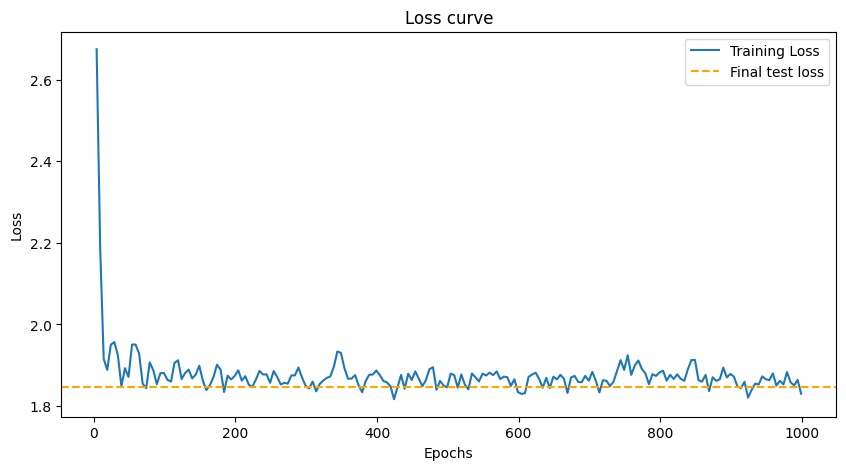

In [373]:
import matplotlib.pyplot as plt

### Visualize loss progression ###
plt.figure(figsize=(10, 5))
plt.plot(epoch_count, loss_values, label="Training Loss")
plt.axhline(y = test_loss.item(), linestyle='dashed', color='orange', label="Final test loss")
plt.title("Loss curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

/tmp/ipykernel_1321867/2884063082.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_1321867/2884063082.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


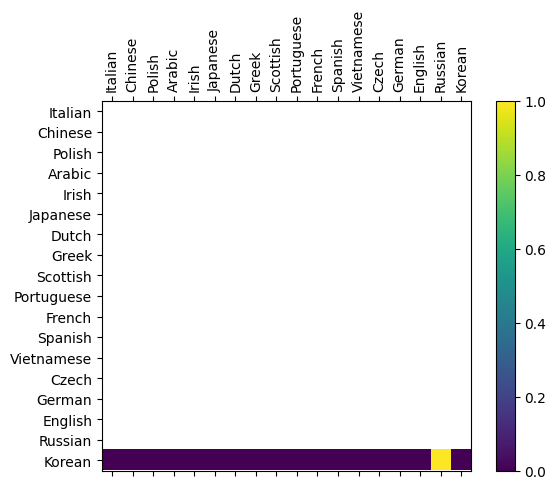

In [374]:
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

def evaluate(line):
    model.eval()
    with torch.inference_mode():
        outputs = model(line.to(device))
    
    return outputs.detach()

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    ix = torch.randint(0, Xtr.shape[0], (1,))
    Xb = Xtr[ix]
    logits = evaluate(Xb)
    guess, guess_i = categoryFromOutput(logits.detach())
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Set up plot
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

In [375]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(encode_line(input_line).unsqueeze(0))

        # print(F.softmax(output))

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Dovesky')
predict('Jackson')
predict('Marijn')


> Dovesky
(2.39) Russian
(1.62) English
(0.73) Arabic

> Jackson
(2.39) Russian
(1.62) English
(0.73) Arabic

> Marijn
(2.39) Russian
(1.62) English
(0.73) Arabic
